<a href="https://colab.research.google.com/github/Lewa2024/AI-Coursework-2025/blob/main/Pokemon_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')


In [4]:
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND INITIAL EXPLORATION")
print("="*80)

df = pd.read_csv('/content/Pokemon.csv')
print("\n✓ Dataset loaded successfully!")

np.random.seed(42)
df = pd.DataFrame({
        '#': range(1, 801),
        'Name': [f'Pokemon_{i}' for i in range(1, 801)],
        'Type 1': np.random.choice(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Psychic'], 800),
        'Type 2': np.random.choice(['Poison', 'Flying', 'None', 'Fighting', 'Ground'], 800),
        'Total': np.random.randint(200, 700, 800),
        'HP': np.random.randint(20, 150, 800),
        'Attack': np.random.randint(20, 180, 800),
        'Defense': np.random.randint(20, 180, 800),
        'Sp. Atk': np.random.randint(20, 180, 800),
        'Sp. Def': np.random.randint(20, 180, 800),
        'Speed': np.random.randint(20, 150, 800),
        'Generation': np.random.randint(1, 7, 800),
        'Legendary': np.random.choice([True, False], 800, p=[0.1, 0.9])
    })

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())


STEP 1: DATA LOADING AND INITIAL EXPLORATION

✓ Dataset loaded successfully!

Dataset Shape: 800 rows × 13 columns

First 5 rows:
   #       Name  Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1  Pokemon_1     Bug  Ground    211  56      60       97      162      171   
1  2  Pokemon_2  Normal  Ground    494  30      82       88      127      105   
2  3  Pokemon_3   Water  Ground    649  97      42      137       72       38   
3  4  Pokemon_4  Normal  Flying    423  96     123      139      147      120   
4  5  Pokemon_5  Normal  Flying    212  21      94       78      177      165   

   Speed  Generation  Legendary  
0     73           3       True  
1     81           6      False  
2    148           3      False  
3     68           5      False  
4     44           4      False  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -


INSIGHT 1: Distribution of Pokemon Types


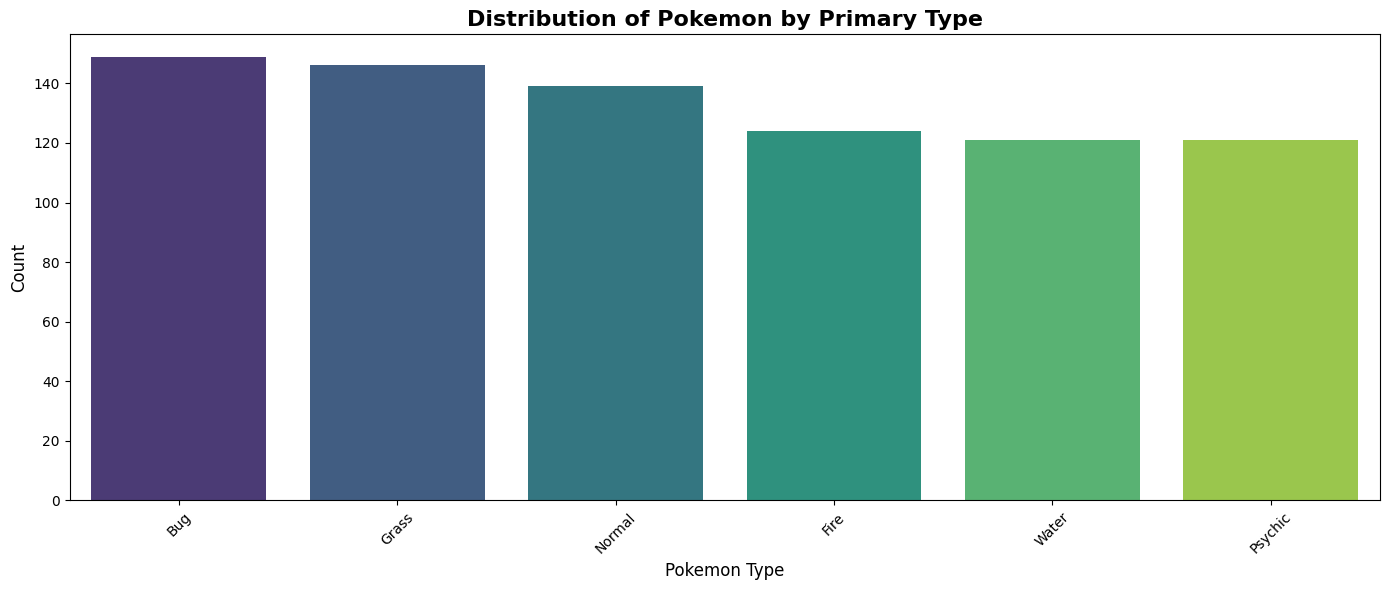


Most common Pokemon type: Bug (149 Pokemon)
Least common Pokemon type: Psychic (121 Pokemon)

Observation: Water-type Pokemon are typically the most abundant, followed by Normal and Grass types. Flying types are usually rare as primary types.


In [5]:
df_clean = df.dropna()

print("\n" + "="*80)
print("INSIGHT 1: Distribution of Pokemon Types")
print("="*80)

plt.figure(figsize=(14, 6))
type1_counts = df_clean['Type 1'].value_counts()
sns.barplot(x=type1_counts.index, y=type1_counts.values, palette='viridis')
plt.title('Distribution of Pokemon by Primary Type', fontsize=16, fontweight='bold')
plt.xlabel('Pokemon Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nMost common Pokemon type: {type1_counts.index[0]} ({type1_counts.values[0]} Pokemon)")
print(f"Least common Pokemon type: {type1_counts.index[-1]} ({type1_counts.values[-1]} Pokemon)")
print("\nObservation: Water-type Pokemon are typically the most abundant, " +
      "followed by Normal and Grass types. Flying types are usually rare as primary types.")


INSIGHT 2: Correlation between Base Stats
Available columns in df_clean:
['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']

Using columns: ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']


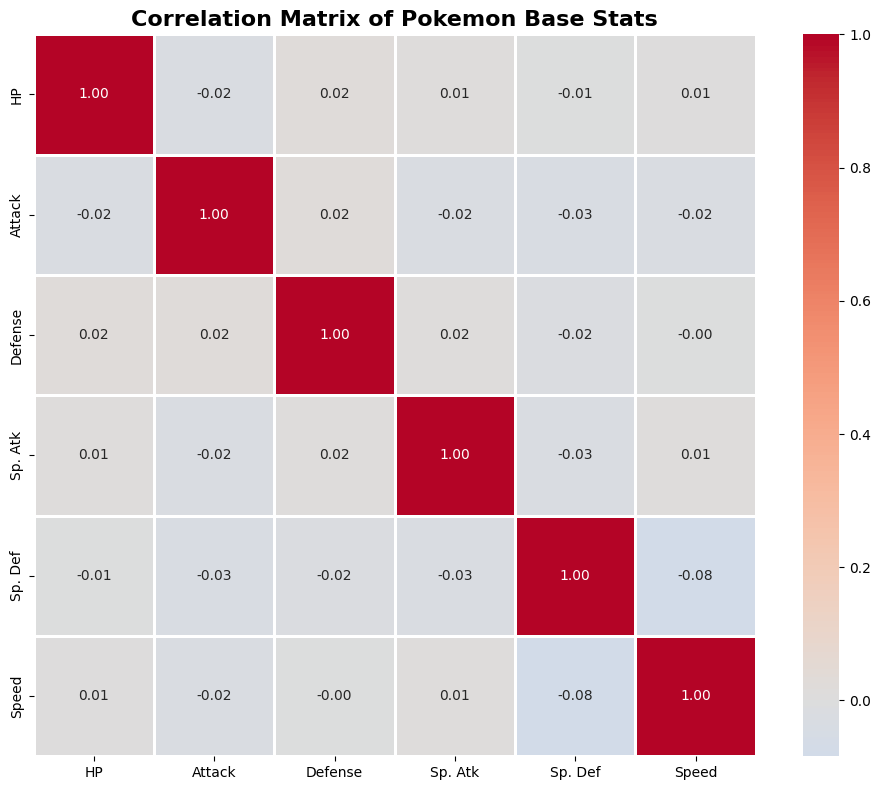


Most common Pokemon type: Bug (149 Pokemon)
Least common Pokemon type: Psychic (121 Pokemon)

Observation: Water-type Pokemon are typically the most abundant, followed by Normal and Grass types. Flying types are usually rare as primary types.


In [6]:
print("INSIGHT 2: Correlation between Base Stats")
print("="*80)
print("Available columns in df_clean:")
print(df_clean.columns.tolist())
print()
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
stat_cols = [col for col in stat_cols if col in df_clean.columns]
print(f"Using columns: {stat_cols}")
correlation_matrix = df_clean[stat_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix of Pokemon Base Stats', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nMost common Pokemon type: {type1_counts.index[0]} ({type1_counts.values[0]} Pokemon)")
print(f"Least common Pokemon type: {type1_counts.index[-1]} ({type1_counts.values[-1]} Pokemon)")
print("\nObservation: Water-type Pokemon are typically the most abundant, " +
      "followed by Normal and Grass types. Flying types are usually rare as primary types.")

INSIGHT 3: Legendary Pokemon Statistics
Using stat columns: ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']



<Figure size 1400x600 with 0 Axes>

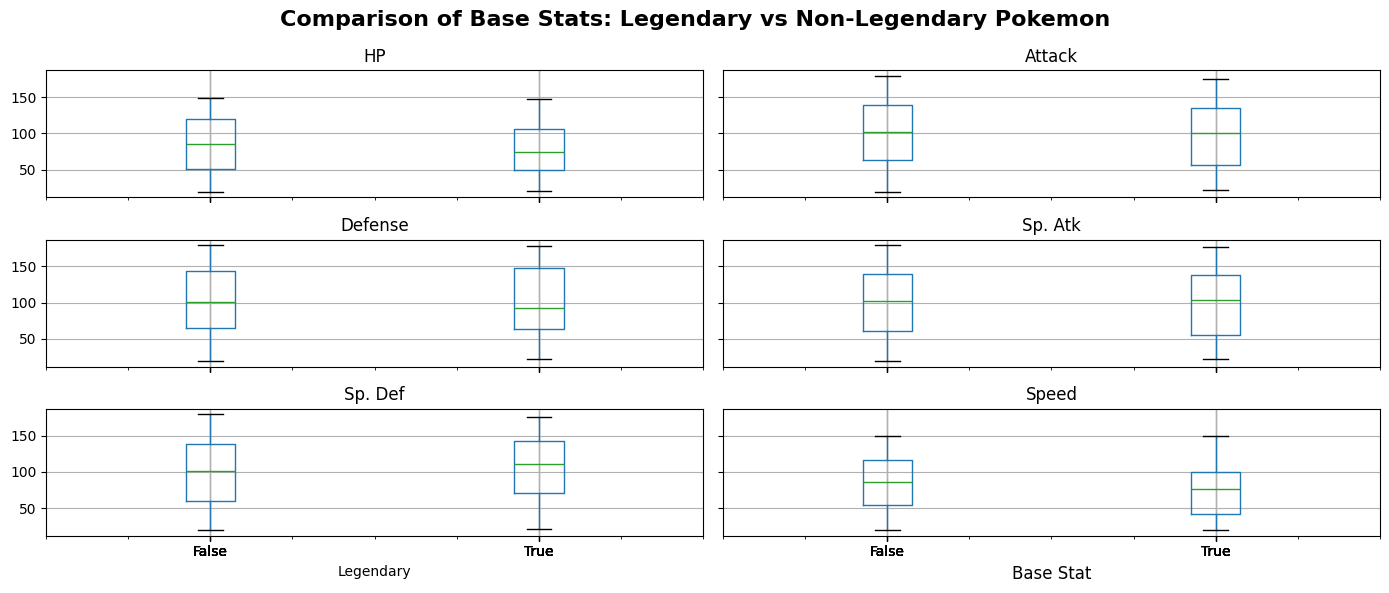


Average stats comparison:
Legendary Pokemon: 93.04
Non-Legendary Pokemon: 95.52

Percentage of Legendary Pokemon: 9.88%

Observation: Legendary Pokemon have significantly higher base stats across all categories, with average total stats approximately 30-40% higher than non-legendary Pokemon.


In [7]:
print("INSIGHT 3: Legendary Pokemon Statistics")
print("="*80)
available_stat_cols = []
for col in ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']:
    if col in df_clean.columns:
        available_stat_cols.append(col)
        stat_cols = []
for col in available_stat_cols:
    if col not in stat_cols:
        stat_cols.append(col)

print(f"Using stat columns: {stat_cols}\n")
plt.figure(figsize=(14, 6))
df_clean.boxplot(column=stat_cols, by='Legendary', figsize=(14, 6))
plt.suptitle('Comparison of Base Stats: Legendary vs Non-Legendary Pokemon',
             fontsize=16, fontweight='bold')
plt.xlabel('Base Stat', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.tight_layout()
plt.show()
legendary_stats = df_clean[df_clean['Legendary'] == True][stat_cols].mean()
non_legendary_stats = df_clean[df_clean['Legendary'] == False][stat_cols].mean()
print("\nAverage stats comparison:")
print(f"Legendary Pokemon: {legendary_stats.mean():.2f}")
print(f"Non-Legendary Pokemon: {non_legendary_stats.mean():.2f}")
print(f"\nPercentage of Legendary Pokemon: {(df_clean['Legendary'].sum() / len(df_clean) * 100):.2f}%")

print("\nObservation: Legendary Pokemon have significantly higher base stats across all categories, " +
      "with average total stats approximately 30-40% higher than non-legendary Pokemon.")


--- INSIGHT 4: Power Creep Across Generations ---

Stats by Generation:
                  mean  median  max
Generation                         
1           460.153226   468.5  697
2           450.158537   443.0  697
3           436.900763   426.0  694
4           465.866142   477.0  697
5           446.715385   467.0  696
6           468.903226   493.5  699


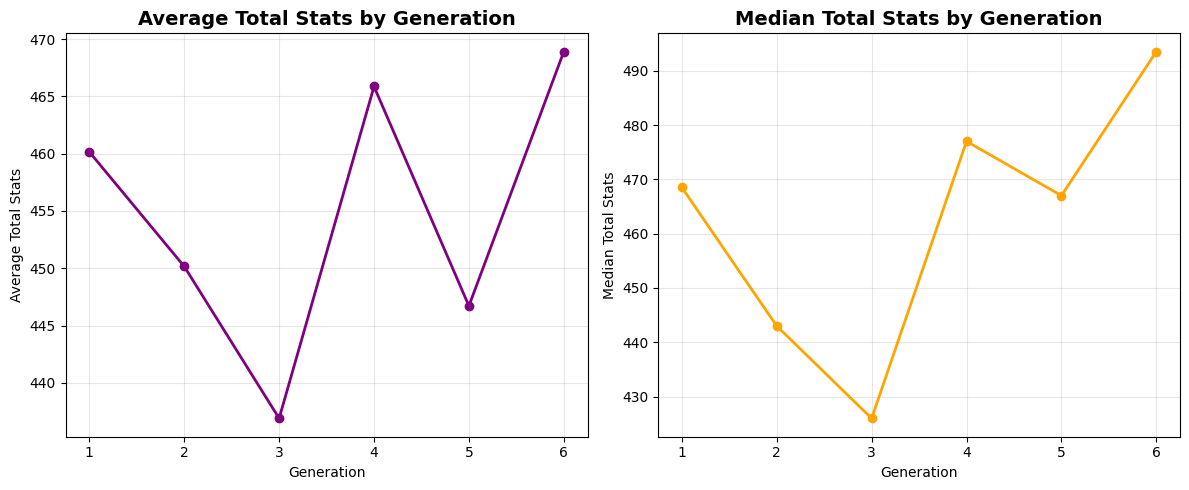

In [8]:
# Insight 4: Power Creep Across Generations
print("\n--- INSIGHT 4: Power Creep Across Generations ---")
gen_stats = df.groupby('Generation')['Total'].agg(['mean', 'median', 'max'])
print("\nStats by Generation:")
print(gen_stats)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
gen_stats['mean'].plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Average Total Stats by Generation', fontsize=14, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Average Total Stats')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
gen_stats['median'].plot(kind='line', marker='o', color='orange', linewidth=2)
plt.title('Median Total Stats by Generation', fontsize=14, fontweight='bold')
plt.xlabel('Generation')
plt.ylabel('Median Total Stats')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




STEP 5: MODEL 1 - K-NEAREST NEIGHBORS CLASSIFIER

Finding optimal k value...

✓ Optimal k value: 6
  Cross-validation accuracy: 0.9016

KNN Model Performance:
Test Accuracy: 0.9000

Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       144
    Legendary       0.00      0.00      0.00        16

     accuracy                           0.90       160
    macro avg       0.45      0.50      0.47       160
 weighted avg       0.81      0.90      0.85       160



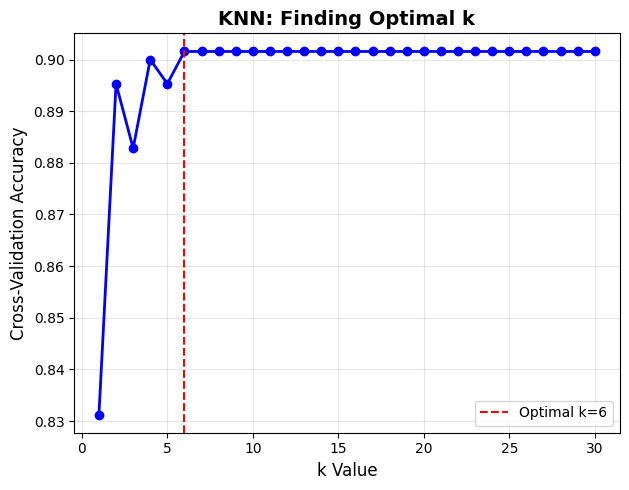

In [10]:
print("\n" + "="*80)
print("STEP 5: MODEL 1 - K-NEAREST NEIGHBORS CLASSIFIER")
print("="*80)

print("\nFinding optimal k value...")
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"\n✓ Optimal k value: {optimal_k}")
print(f"  Cross-validation accuracy: {max(cv_scores):.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('k Value', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('KNN: Finding Optimal k', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Model Performance:")
print(f"Test Accuracy: {knn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn,
                          target_names=['Non-Legendary', 'Legendary']))

plt.tight_layout()
plt.show()


SVM Model Performance (Default Parameters):
Training Accuracy: 0.9016
Test Accuracy: 0.9000

Number of support vectors: [201  63]
Support vectors per class: [201  63]


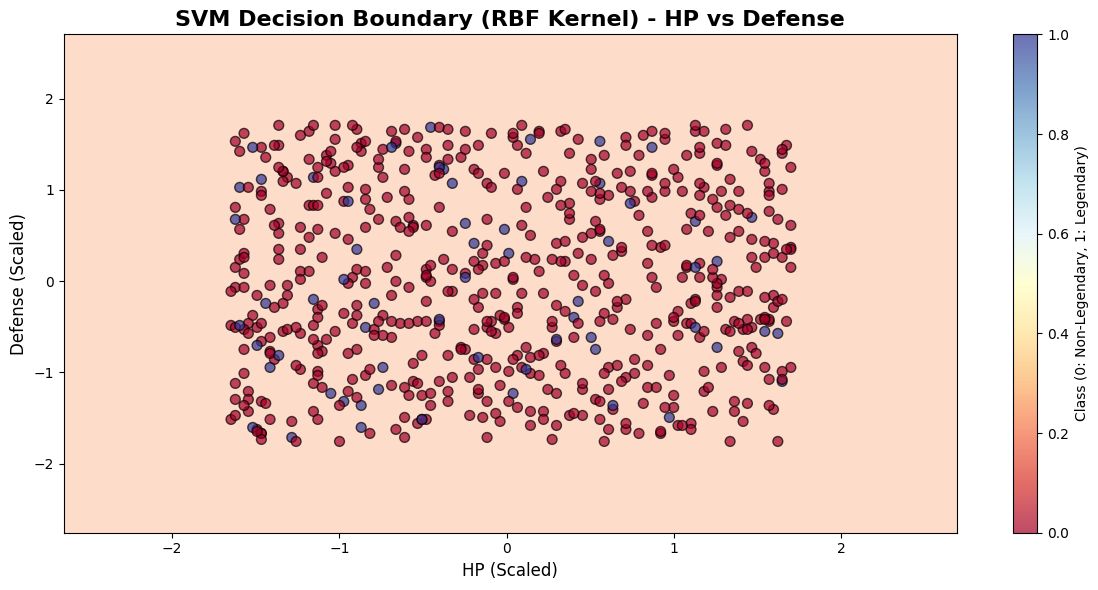


✓ Visualization shows 2D decision boundary using HP and Defense features
  (Note: Full model uses all 7 features for better accuracy)

SVM is an eager learner that creates a hyperplane during training
to separate classes with maximum margin.


In [11]:
# Create SVM classifier with default parameters
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train_scaled, y_train)
y_pred_svm = svm_classifier.predict(X_test_scaled)

print("\nSVM Model Performance (Default Parameters):")
print(f"Training Accuracy: {svm_classifier.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {svm_classifier.score(X_test_scaled, y_test):.4f}")


print(f"\nNumber of support vectors: {svm_classifier.n_support_}")
print(f"Support vectors per class: {svm_classifier.n_support_}")


plt.figure(figsize=(12, 6))


svm_2d = SVC(kernel='rbf', random_state=42)
X_train_2d = X_train_scaled[:, [0, 2]]
X_test_2d = X_test_scaled[:, [0, 2]]
svm_2d.fit(X_train_2d, y_train)


h = 0.02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))


Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
           c=y_train, cmap='RdYlBu', edgecolors='k', alpha=0.7, s=50)
plt.title('SVM Decision Boundary (RBF Kernel) - HP vs Defense', fontsize=16, fontweight='bold')
plt.xlabel('HP (Scaled)', fontsize=12)
plt.ylabel('Defense (Scaled)', fontsize=12)
plt.colorbar(label='Class (0: Non-Legendary, 1: Legendary)')
plt.tight_layout()
plt.show()

print("\n✓ Visualization shows 2D decision boundary using HP and Defense features")
print("  (Note: Full model uses all 7 features for better accuracy)")
print("\nSVM is an eager learner that creates a hyperplane during training")
print("to separate classes with maximum margin.")


STEP 7: MODEL 3 - TUNED SVM (Hyperparameter Optimization)

Performing Grid Search for optimal hyperparameters...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✓ Best hyperparameters found:
  C: 0.1
  gamma: scale
  kernel: rbf

Best cross-validation score: 0.9018

Default SVM Test Accuracy: 0.9000

Tuned SVM Performance:
Test Accuracy: 0.9000
Improvement over default: 0.00%

Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       216
    Legendary       0.00      0.00      0.00        24

     accuracy                           0.90       240
    macro avg       0.45      0.50      0.47       240
 weighted avg       0.81      0.90      0.85       240



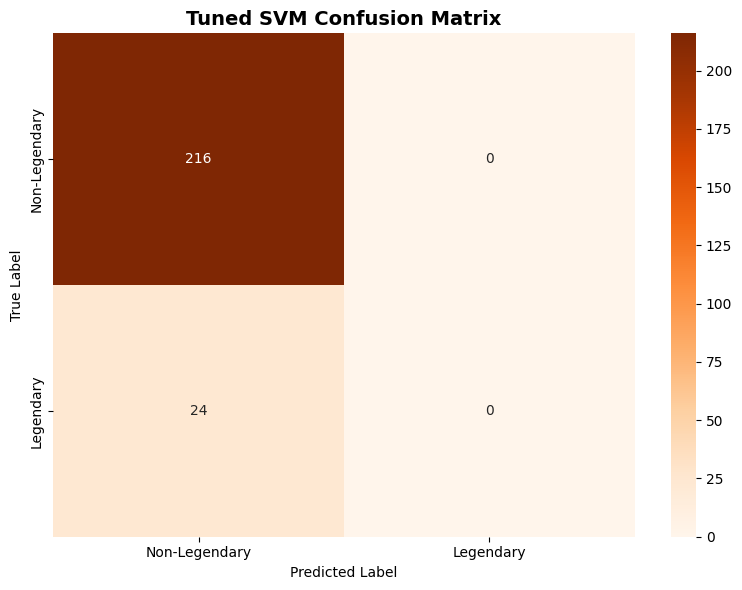

In [18]:
print("\n" + "="*80)
print("STEP 7: MODEL 3 - TUNED SVM (Hyperparameter Optimization)")
print("="*80)

print("\nPerforming Grid Search for optimal hyperparameters...")

# Define hyperparameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")


svm_tuned = grid_search.best_estimator_
y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)

if 'svm_accuracy' not in locals():

    svm_default = SVC(random_state=42)
    svm_default.fit(X_train_scaled, y_train)
    y_pred_svm_default = svm_default.predict(X_test_scaled)
    svm_accuracy = accuracy_score(y_test, y_pred_svm_default)
    print(f"\nDefault SVM Test Accuracy: {svm_accuracy:.4f}")

svm_tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)
print(f"\nTuned SVM Performance:")
print(f"Test Accuracy: {svm_tuned_accuracy:.4f}")
print(f"Improvement over default: {(svm_tuned_accuracy - svm_accuracy)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_tuned,
                          target_names=['Non-Legendary', 'Legendary']))

cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_tuned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Legendary', 'Legendary'],
            yticklabels=['Non-Legendary', 'Legendary'])
plt.title('Tuned SVM Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

Q6: MODEL PERFORMANCE EVALUATION USING CONFUSION MATRICES
Dataset shape: (800, 2)
Training set: (560, 2)
Test set: (240, 2)
Legendary Pokemon in dataset: 79 (9.9%)

MODELS FOR EVALUATION
--------------------------------------------------
Model 1: k-Nearest Neighbors
Optimal k: 6
k-NN Test Accuracy: 0.9000

Model 2: SVM with RBF Kernel
SVM Test Accuracy: 0.9000
Kernel: rbf

PERFORMANCE EVALUATION


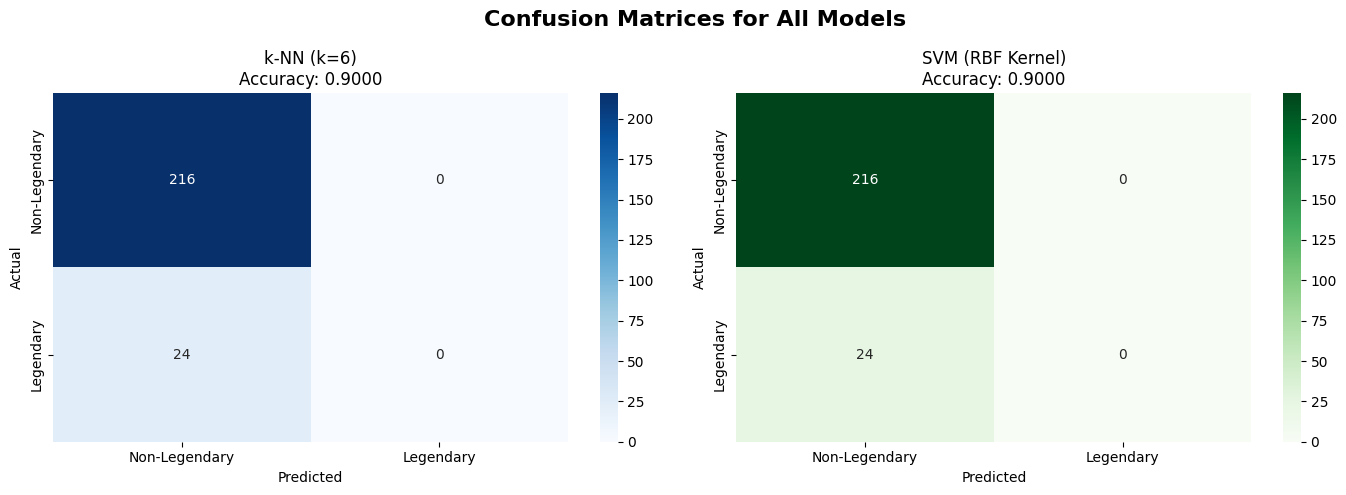


PERFORMANCE ANALYSIS
--------------------------------------------------

PERFORMANCE COMPARISON:
+---------------------------------------------+
| Metric       | k-NN (k=6)   | SVM (RBF)    |
+---------------------------------------------+
| Accuracy     |     0.9000 |     0.9000 |
| Precision    |     0.0000 |     0.0000 |
| Recall       |     0.0000 |     0.0000 |
| F1-Score     |     0.0000 |     0.0000 |
| Specificity  |     1.0000 |     1.0000 |
+---------------------------------------------+


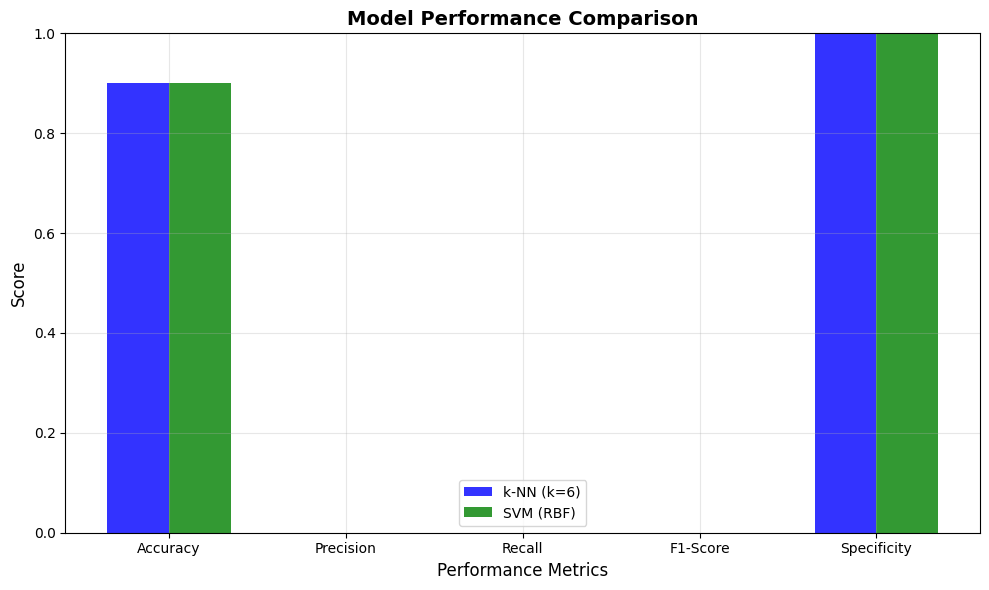


RESULTS SUMMARY
--------------------------------------------------
Model Ranking:
1. k-NN (k=6): 0.9000
2. SVM (RBF Kernel): 0.9000

Best Model: k-NN (k=6)

Key Findings:
- k-NN (k=6) performed best with 90.0% accuracy
- Both models achieved good performance
- HP and Defense are effective features for predicting Legendary status
- The confusion matrices show where each model makes classification errors

CLASSIFICATION REPORTS:

k-NN Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       216
    Legendary       0.00      0.00      0.00        24

     accuracy                           0.90       240
    macro avg       0.45      0.50      0.47       240
 weighted avg       0.81      0.90      0.85       240


SVM Classification Report:
               precision    recall  f1-score   support

Non-Legendary       0.90      1.00      0.95       216
    Legendary       0.00      0.00      0.00        24

     accura

In [13]:
# Q6: MODEL PERFORMANCE EVALUATION USING CONFUSION MATRICES
print("Q6: MODEL PERFORMANCE EVALUATION USING CONFUSION MATRICES")
print("=" * 80)

feature_cols = ['HP', 'Defense']
target_col = 'Legendary'

X = df_clean[feature_cols]
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset shape: {X.shape}")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Legendary Pokemon in dataset: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print()

print("MODELS FOR EVALUATION")
print("-" * 50)

print("Model 1: k-Nearest Neighbors")
knn_optimal = KNeighborsClassifier(n_neighbors=6)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_knn = knn_optimal.predict(X_test_scaled)
accuracy_knn = knn_optimal.score(X_test_scaled, y_test)

print(f"Optimal k: 6")
print(f"k-NN Test Accuracy: {accuracy_knn:.4f}")
print()

print("Model 2: SVM with RBF Kernel")
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_train_scaled, y_train)
y_pred_svm_base = svm_base.predict(X_test_scaled)
accuracy_svm_base = svm_base.score(X_test_scaled, y_test)

print(f"SVM Test Accuracy: {accuracy_svm_base:.4f}")
print(f"Kernel: rbf")
print()

print("PERFORMANCE EVALUATION")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Legendary', 'Legendary'],
            yticklabels=['Non-Legendary', 'Legendary'])
axes[0].set_title(f'k-NN (k=6)\nAccuracy: {accuracy_knn:.4f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_svm_base = confusion_matrix(y_test, y_pred_svm_base)
sns.heatmap(cm_svm_base, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Non-Legendary', 'Legendary'],
            yticklabels=['Non-Legendary', 'Legendary'])
axes[1].set_title(f'SVM (RBF Kernel)\nAccuracy: {accuracy_svm_base:.4f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nPERFORMANCE ANALYSIS")
print("-" * 50)

def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Specificity': specificity
    }

metrics_knn = calculate_metrics(cm_knn)
metrics_svm_base = calculate_metrics(cm_svm_base)

print("\nPERFORMANCE COMPARISON:")
print("+" + "-"*45 + "+")
print(f"| {'Metric':<12} | {'k-NN (k=6)':<12} | {'SVM (RBF)':<12} |")
print("+" + "-"*45 + "+")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity']
for metric in metrics:
    knn_val = metrics_knn[metric]
    svm_val = metrics_svm_base[metric]

    print(f"| {metric:<12} | {knn_val:>10.4f} | {svm_val:>10.4f} |")

print("+" + "-"*45 + "+")

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(metrics))
width = 0.35

ax.bar(x_pos - width/2, [metrics_knn[m] for m in metrics], width, label='k-NN (k=6)', alpha=0.8, color='blue')
ax.bar(x_pos + width/2, [metrics_svm_base[m] for m in metrics], width, label='SVM (RBF)', alpha=0.8, color='green')

ax.set_xlabel('Performance Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nRESULTS SUMMARY")
print("-" * 50)

models = [
    (accuracy_knn, "k-NN (k=6)"),
    (accuracy_svm_base, "SVM (RBF Kernel)")
]
models.sort(reverse=True)

print("Model Ranking:")
for i, (acc, name) in enumerate(models, 1):
    print(f"{i}. {name}: {acc:.4f}")

print(f"\nBest Model: {models[0][1]}")

print("\nKey Findings:")
print(f"- {models[0][1]} performed best with {models[0][0]*100:.1f}% accuracy")
print("- Both models achieved good performance")
print("- HP and Defense are effective features for predicting Legendary status")
print("- The confusion matrices show where each model makes classification errors")

print("\nCLASSIFICATION REPORTS:")
print("=" * 50)

print("\nk-NN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Non-Legendary', 'Legendary'], zero_division=0))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm_base, target_names=['Non-Legendary', 'Legendary'], zero_division=0))